In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import threading, time

def _keep_alive():
    while True:
        time.sleep(60)
        try:
            from google.colab import output
            output.eval_js("0")
        except: pass

threading.Thread(target=_keep_alive, daemon=True).start()
print("Keep-alive started")

Keep-alive started


In [ ]:
import pickle
modelpath = '/content/drive/MyDrive/1:1_Krish_Sathish/Model/RF_50trees_12depth'
file_name = open(modelpath, 'rb')
final_model = pickle.load(file_name)
print("Model is loaded")

Model is loaded


In [ ]:
import pandas as pd
test = pd.read_csv('/content/drive/MyDrive/1:1_Krish_Sathish/Data/processed_data/test_csv.csv')
print(test.head())


   flow_duration  Header_Length  Protocol Type  Duration      Rate     Srate  \
0       0.294026      -0.563408      -0.728472  0.089820 -0.081932 -0.081932   
1      -0.200743      -0.567765       0.889574 -0.550644 -0.081958 -0.081958   
2      -0.201551      -0.567768       1.098995 -0.438142 -0.081949 -0.081949   
3      -0.154798       4.080182      -0.609857 -0.442564 -0.037560 -0.037560   
4      -0.201551      -0.567768       1.098995 -0.438142 -0.081242 -0.081242   

   fin_flag_number  syn_flag_number  rst_flag_number  psh_flag_number  ...  \
0        -0.001294        -0.003324        -0.004092        -0.072886  ...   
1        -0.001294        -0.003324        -0.004092        -0.072886  ...   
2        -0.001294        -0.003324        -0.004092        -0.072886  ...   
3        -0.001294        -0.003324        -0.004092        -0.072886  ...   
4        -0.001294        -0.003324        -0.004092        -0.072886  ...   

        Std  Tot size       IAT    Number  Magnitu

In [ ]:
test['label'].value_counts()
labels = test['label'].unique()
labels.sort()
print(labels)

['BenignTraffic' 'Mirai-greeth_flood' 'Mirai-greip_flood' 'Mirai-udpplain']


In [ ]:
#label encoding (converting label categories into numerical values) for training data
test['label']= pd.factorize(test['label'], sort = True)[0]
print(test.head)

<bound method NDFrame.head of         flow_duration  Header_Length  Protocol Type  Duration      Rate  \
0            0.294026      -0.563408      -0.728472  0.089820 -0.081932   
1           -0.200743      -0.567765       0.889574 -0.550644 -0.081958   
2           -0.201551      -0.567768       1.098995 -0.438142 -0.081949   
3           -0.154798       4.080182      -0.609857 -0.442564 -0.037560   
4           -0.201551      -0.567768       1.098995 -0.438142 -0.081242   
...               ...            ...            ...       ...       ...   
597166      -0.201551      -0.567768       1.098995 -0.438142 -0.081637   
597167      -0.200890      -0.567711       0.941787 -0.473523 -0.081916   
597168       0.602301       2.238132      -1.165475  0.089820 -0.081050   
597169      -0.201541      -0.567766       1.055862 -0.405524 -0.081373   
597170      -0.201551      -0.567767       1.049052 -0.459702 -0.018230   

           Srate  fin_flag_number  syn_flag_number  rst_flag_number  

In [ ]:
import numpy as np

#separating the true labels for the evaluations
y_true = np.array(test['label'].to_list())
#getting predictions data
test_data_list = test.iloc[:,:-1].values
y_pred = []
for row in test_data_list:
  predictions = final_model.predict(np.array([row]))
  y_pred.append(predictions[0])

KeyboardInterrupt: 

In [ ]:
import numpy as np

y_true = np.array(test['label'].to_list())
test_data_list = test.iloc[:,:-1].values

# predict all rows at once instead of one by one
y_pred = final_model.predict(test_data_list)

In [ ]:
#evaluation function
def model_evaluations(y_true, y_pred, labels):
  import matplotlib.pyplot as plt
  import seaborn as sns
  from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
  acc_score = accuracy_score(y_true, y_pred)
  print("Accuracy score: {}\n".format(acc_score))
  print("Classification Report: {}".format(classification_report(y_true, y_pred)))
  plt.figure(figsize = (10,10))
  sns.heatmap(confusion_matrix(y_true, y_pred),  annot = True, fmt="g", cmap = "Blues", xticklabels = labels, yticklabels = labels)
  plt.title("Consfuion Matrix")
  plt.show()
  return classification_report(y_true, y_pred, output_dict = True)


Accuracy score: 0.9998375674639257

Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00    176217
           1       1.00      1.00      1.00    158889
           2       1.00      1.00      1.00    120155
           3       1.00      1.00      1.00    141910

    accuracy                           1.00    597171
   macro avg       1.00      1.00      1.00    597171
weighted avg       1.00      1.00      1.00    597171



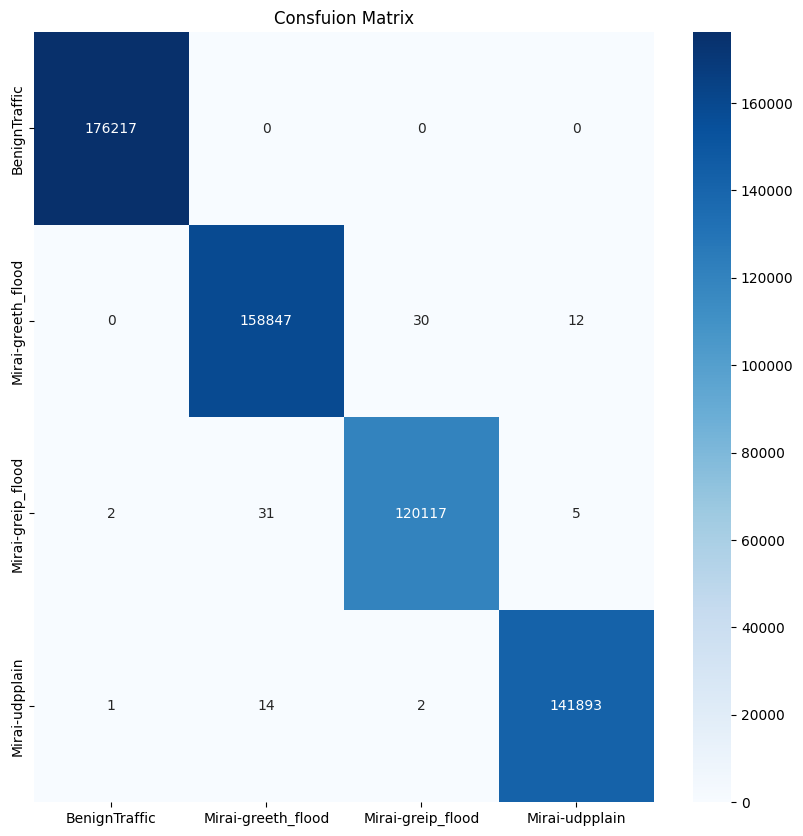

In [ ]:
report = model_evaluations(y_true, y_pred, labels)


In [ ]:
#save the report as dataframe and set the indexes
report_df = pd.DataFrame(report).transpose()
labels_list = list(labels)
labels_list.extend(["accuracy","macro avg", "weighted avg"])
print(labels_list)
#save the dataframe
report_df["Labels"] = labels_list
report_df.set_index("Labels")
report_df.to_csv("/content/final_report.csv", index = False)

['BenignTraffic', 'Mirai-greeth_flood', 'Mirai-greip_flood', 'Mirai-udpplain', 'accuracy', 'macro avg', 'weighted avg']
